# DAT341: Programming assignment 1: Introduction to ML workflow and decision trees

Group: PA1 14

Members:
1.   Zheng Wei Liau (liau@chalmers.se)
2.   Jared Ng (jaredn@chalmers.se)


# Task 1: A classification example: fetal heart condition diagnosis

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the CSV file.
data = pd.read_csv('CTG.csv', skiprows=1)

# Select the relevant numerical columns.
selected_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
                 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
                 'Median', 'Variance', 'Tendency', 'NSP']
data = data[selected_cols].dropna()

# Shuffle the dataset.
data_shuffled = data.sample(frac=1.0, random_state=0)

# Split into input part X and output part Y.
X = data_shuffled.drop('NSP', axis=1)

# Map the diagnosis code to a human-readable label.
def to_label(y):
    return [None, 'normal', 'suspect', 'pathologic'][(int(y))]

Y = data_shuffled['NSP'].apply(to_label)

# Partition the data into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

In [ ]:
X.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
658,130.0,1.0,0.0,3.0,0.0,0.0,0.0,24.0,1.2,12.0,...,35.0,120.0,155.0,1.0,0.0,134.0,133.0,135.0,1.0,0.0
1734,134.0,9.0,1.0,8.0,5.0,0.0,0.0,59.0,1.2,0.0,...,109.0,80.0,189.0,6.0,0.0,150.0,146.0,150.0,33.0,0.0
1226,125.0,1.0,0.0,4.0,0.0,0.0,0.0,43.0,0.7,31.0,...,21.0,120.0,141.0,0.0,0.0,131.0,130.0,132.0,1.0,0.0
1808,143.0,0.0,0.0,1.0,0.0,0.0,0.0,69.0,0.3,6.0,...,27.0,132.0,159.0,1.0,0.0,145.0,144.0,146.0,1.0,0.0
825,152.0,0.0,0.0,4.0,0.0,0.0,0.0,62.0,0.4,59.0,...,25.0,136.0,161.0,0.0,0.0,159.0,156.0,158.0,1.0,1.0


### Dummy Classifier

In [ ]:
from sklearn.dummy import DummyClassifier

clf = DummyClassifier(strategy='most_frequent')

In [ ]:
from sklearn.model_selection import cross_val_score

DCscore = cross_val_score(clf, Xtrain, Ytrain)
print(DCscore)

[0.78235294 0.78235294 0.77941176 0.77941176 0.77941176]


The cross_val_score function returns an array with accuracies on (default 5) different folds in cross validation. The mean of these 5 accuracies are then taken to get a single score per classifier that can be used to compare to other classifiers.

In [ ]:
DCscore.mean()

np.float64(0.7805882352941176)

From the above code, we can determine the mean accuracy of using a Dummy Classifier to be 78.06%

Following this, different classifiers are tried to obtain a high cross validation accuracy. In this case, we tried using Decision Tree Classifier, Random Forest Classifier and Gradient Boosting Classifier.

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, 15, None],  # Test different depths
    'min_samples_split': [2, 5, 10],     # Minimum samples to split
    'min_samples_leaf': [1, 2, 5],       # Minimum samples per leaf
    'criterion': ['gini', 'entropy']     # Test both impurity measures
}

# Initialize classifier
clf = DecisionTreeClassifier(random_state=0)

# Perform GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(Xtrain, Ytrain)

# Best parameters and cross-validation score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9341176470588234


### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],        # Number of trees
    'max_depth': [5, 10, 20, None],        # Max depth of trees
    'min_samples_split': [2, 5, 10],       # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5],         # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None],  # Number of features to consider for splits
    'bootstrap': [True, False]             # Bootstrapping
}

# Initialize the Random Forest model
clf = RandomForestClassifier(random_state=0)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(Xtrain, Ytrain)

# Print the best parameters and cross-validation score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Score: 0.9441176470588235


### Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],        # Number of trees
    'learning_rate': [0.01, 0.1, 0.2],     # Step size shrinkage
    'max_depth': [3, 5, 10],               # Maximum depth of trees
    'min_samples_split': [2, 5, 10],       # Minimum samples to split
    'min_samples_leaf': [1, 2, 5],         # Minimum samples per leaf
    'subsample': [0.8, 1.0]                # Fraction of samples per tree
}

# Initialize the Gradient Boosting model
clf = GradientBoostingClassifier(random_state=0)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(Xtrain, Ytrain)

# Print the best parameters and cross-validation score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 1.0}
Best Cross-Validation Score: 0.9552941176470588


Classifiers tried with mean accuracy(5sf):
1. Dummy Classifier: 78.059 %

2. Decision Tree Classifier: 93.412 %

3. Random Forest Classifier: 94.412 %

4. Gradient Boosting Classifier: 95.529 %

Among the classifiers tried, we have determined that the best classifier is Gradient Boosting Classifier.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Use the best parameters
clf = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=2,
    min_samples_split=10,
    n_estimators=200,
    subsample=1.0,
    random_state=0  # Ensure reproducibility
)

# Train the model
clf.fit(Xtrain, Ytrain)

# Predict on the test set
Ypred = clf.predict(Xtest)

# Calculate and print the accuracy score
test_accuracy = accuracy_score(Ytest, Ypred)
print("Test Set Accuracy:", test_accuracy)


Test Set Accuracy: 0.9366197183098591


With the high accuracy in the cross validation evaluation, the Gradient Boosting classifier is trained on the whole training set and then evaluated on the test set.

Gradient Boosting Classifier is an ensemble learning algorithm that builds a predictive model by sequentially improving weaker models and is commonly used for structured data classification tasks.

On the test set, the Gradient Boosting Classifier has an accuracy of 93.662% (5sf)

# Task 2: Decision trees for classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#print(plt.style.available)

%config InlineBackend.figure_format = 'svg'
# Pick a style to use from the available style printed above.
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Read the CSV file.
data = pd.read_csv('CTG.csv', skiprows=1)

# Select the relevant numerical columns.
selected_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
                 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
                 'Median', 'Variance', 'Tendency', 'NSP']
data = data[selected_cols].dropna()

# Shuffle the dataset.
data_shuffled = data.sample(frac=1.0, random_state=0)

# Split into input part X and output part Y.
X = data_shuffled.drop('NSP', axis=1)

# Map the diagnosis code to a human-readable label.
def to_label(y):
    return [None, 'normal', 'suspect', 'pathologic'][(int(y))]

Y = data_shuffled['NSP'].apply(to_label)

from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.3, random_state=0)

'''
def plot_boundary(clf, X, Y, cmap='tab10', names=None):

    if isinstance(X, pd.DataFrame):
        if not names:
            names = list(X.columns)
        X = X.to_numpy()

    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()

    x_off = (x_max-x_min)/25
    y_off = (y_max-y_min)/25
    x_min -= x_off
    x_max += x_off
    y_min -= y_off
    y_max += y_off

    xs = np.linspace(x_min, x_max, 250)
    ys = np.linspace(y_min, y_max, 250)

    xx, yy = np.meshgrid(xs, ys)

    lenc = {c:i for i, c in enumerate(clf.classes_)}
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array([lenc[z] for z in Z])
    Z = Z.reshape(xx.shape)
    Yenc = [lenc[y] for y in Y]
    plt.figure(figsize=(5,5))
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.15)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)

    sc = plt.scatter(X[:,0], X[:,1], c=Yenc, cmap=cmap, alpha=0.5, edgecolors='k', linewidths=0.5);

    plt.legend(handles=sc.legend_elements()[0], labels=list(clf.classes_))

    if names:
        plt.xlabel(names[0])
        plt.ylabel(names[1])
'''

class DecisionTreeLeaf:

    def __init__(self, value):
        self.value = value

    # This method computes the prediction for this leaf node. This will just return a constant value.
    def predict(self, x):
        return self.value

    # Utility function to draw a tree visually using graphviz.
    def draw_tree(self, graph, node_counter, names):
        node_id = str(node_counter)
        val_str = f'{self.value:.4g}' if isinstance(self.value, float) else str(self.value)
        graph.node(node_id, val_str, style='filled')
        return node_counter+1, node_id

    def __eq__(self, other):
        if isinstance(other, DecisionTreeLeaf):
            return self.value == other.value
        else:
            return False
#A branch will look at one feature, and will select a subtree depending on the
# value of the feature. That subtree will then be called recursively to compute
# the prediction.

#This implementation assumes that the feature is numerical. Depending on whether
# the feature is or isn't greater than a threshold, the "high" or "low" subtree
# will be selected.

class DecisionTreeBranch:

    def __init__(self, feature, threshold, low_subtree, high_subtree):
        self.feature = feature
        self.threshold = threshold
        self.low_subtree = low_subtree
        self.high_subtree = high_subtree

    # For a branch node, we compute the prediction by first considering the feature, and then
    # calling the upper or lower subtree, depending on whether the feature is or isn't greater
    # than the threshold.
    def predict(self, x):
        if x[self.feature] <= self.threshold:
            return self.low_subtree.predict(x)
        else:
            return self.high_subtree.predict(x)

    # Utility function to draw a tree visually using graphviz.
    def draw_tree(self, graph, node_counter, names):
        node_counter, low_id = self.low_subtree.draw_tree(graph, node_counter, names)
        node_counter, high_id = self.high_subtree.draw_tree(graph, node_counter, names)
        node_id = str(node_counter)
        fname = f'F{self.feature}' if names is None else names[self.feature]
        lbl = f'{fname} > {self.threshold:.4g}?'
        graph.node(node_id, lbl, shape='box', fillcolor='yellow', style='filled, rounded')
        graph.edge(node_id, low_id, 'False')
        graph.edge(node_id, high_id, 'True')
        return node_counter+1, node_id

#get_default_value: what output value to use if we decide to return a leaf node.
#                   For classification, this will be the most common output
#                   value, while for regression it will be the mean.

#is_homogeneous: tests whether a set of output values is homogeneous. For
#                classification, this means that all outputs are identical; for
#                regression, we'll probably test whether the variance is smaller
#                than some threshold.

#best_split: finds the best splitting point for that feature. For classification,
#            this will be based on one of the classification criteria
#            (information gain, gini impurity, majority sum); for regression, it
#            will be based on variances in the subsets.

from graphviz import Digraph
from sklearn.base import BaseEstimator, ClassifierMixin
from abc import ABC, abstractmethod

class DecisionTree(ABC, BaseEstimator):

    def __init__(self, max_depth):
        super().__init__()
        self.max_depth = max_depth

    # As usual in scikit-learn, the training method is called *fit*. We first process the dataset so that
    # we're sure that it's represented as a NumPy matrix. Then we call the recursive tree-building method
    # called make_tree (see below).
    def fit(self, X, Y):
        if isinstance(X, pd.DataFrame):
            self.names = X.columns
            X = X.to_numpy()
        elif isinstance(X, list):
            self.names = None
            X = np.array(X)
        else:
            self.names = None
        Y = np.array(Y)
        self.root = self.make_tree(X, Y, self.max_depth)

    def draw_tree(self):
        graph = Digraph()
        self.root.draw_tree(graph, 0, self.names)
        return graph

    # By scikit-learn convention, the method *predict* computes the classification or regression output
    # for a set of instances.
    # To implement it, we call a separate method that carries out the prediction for one instance.
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        return [self.predict_one(x) for x in X]

    # Predicting the output for one instance.
    def predict_one(self, x):
        return self.root.predict(x)

    # This is the recursive training
    def make_tree(self, X, Y, max_depth):

        # We start by computing the default value that will be used if we'll return a leaf node.
        # For classifiers, this will be the most common value in Y.
        default_value = self.get_default_value(Y)

        # First the two base cases in the recursion: is the training set completely
        # homogeneous, or have we reached the maximum depth? Then we need to return a leaf.

        # If we have reached the maximum depth, return a leaf with the majority value.
        if max_depth == 0:
            return DecisionTreeLeaf(default_value)

        # If all the instances in the remaining training set have the same output value,
        # return a leaf with this value.
        if self.is_homogeneous(Y):
            return DecisionTreeLeaf(default_value)

        # Select the "most useful" feature and split threshold. To rank the "usefulness" of features,
        # we use one of the classification or regression criteria.
        # For each feature, we call best_split (defined in a subclass). We then maximize over the features.
        n_features = X.shape[1]
        _, best_feature, best_threshold = max(self.best_split(X, Y, feature) for feature in range(n_features))

        if best_feature is None:
            return DecisionTreeLeaf(default_value)

        # Split the training set into subgroups, based on whether the selected feature is greater than
        # the threshold or not
        X_low, X_high, Y_low, Y_high = self.split_by_feature(X, Y, best_feature, best_threshold)

        # Build the subtrees using a recursive call. Each subtree is associated
        # with a value of the feature.
        low_subtree = self.make_tree(X_low, Y_low, max_depth-1)
        high_subtree = self.make_tree(X_high, Y_high, max_depth-1)

        if low_subtree == high_subtree:
            return low_subtree

        # Return a decision tree branch containing the result.
        return DecisionTreeBranch(best_feature, best_threshold, low_subtree, high_subtree)

    # Utility method that splits the data into the "upper" and "lower" part, based on a feature
    # and a threshold.
    def split_by_feature(self, X, Y, feature, threshold):
        low = X[:,feature] <= threshold
        high = ~low
        return X[low], X[high], Y[low], Y[high]

    # The following three methods need to be implemented by the classification and regression subclasses.

    @abstractmethod
    def get_default_value(self, Y):
        pass

    @abstractmethod
    def is_homogeneous(self, Y):
        pass

    @abstractmethod
    def best_split(self, X, Y, feature):
        pass

from collections import Counter

class TreeClassifier(DecisionTree, ClassifierMixin):

    def __init__(self, max_depth=10, criterion='maj_sum'):
        super().__init__(max_depth)
        self.criterion = criterion

    def fit(self, X, Y):
        # For decision tree classifiers, there are some different ways to measure
        # the homogeneity of subsets.
        if self.criterion == 'maj_sum':
            self.criterion_function = majority_sum_scorer
        elif self.criterion == 'info_gain':
            self.criterion_function = info_gain_scorer
        elif self.criterion == 'gini':
            self.criterion_function = gini_scorer
        else:
            raise Exception(f'Unknown criterion: {self.criterion}')
        super().fit(X, Y)
        self.classes_ = sorted(set(Y))

    # Select a default value that is going to be used if we decide to make a leaf.
    # We will select the most common value.
    def get_default_value(self, Y):
        self.class_distribution = Counter(Y)
        return self.class_distribution.most_common(1)[0][0]

    # Checks whether a set of output values is homogeneous. In the classification case,
    # this means that all output values are identical.
    # We assume that we called get_default_value just before, so that we can access
    # the class_distribution attribute. If the class distribution contains just one item,
    # this means that the set is homogeneous.
    def is_homogeneous(self, Y):
        return len(self.class_distribution) == 1

    # Finds the best splitting point for a given feature. We'll keep frequency tables (Counters)
    # for the upper and lower parts, and then compute the impurity criterion using these tables.
    # In the end, we return a triple consisting of
    # - the best score we found, according to the criterion we're using
    # - the id of the feature
    # - the threshold for the best split
    def best_split(self, X, Y, feature):

        # Create a list of input-output pairs, where we have sorted
        # in ascending order by the input feature we're considering.
        sorted_indices = np.argsort(X[:, feature])
        X_sorted = list(X[sorted_indices, feature])
        Y_sorted = list(Y[sorted_indices])

        n = len(Y)

        # The frequency tables corresponding to the parts *before and including*
        # and *after* the current element.
        low_distr = Counter()
        high_distr = Counter(Y)

        # Keep track of the best result we've seen so far.
        max_score = -np.inf
        max_i = None

        # Go through all the positions (excluding the last position).
        for i in range(0, n-1):

            # Input and output at the current position.
            x_i = X_sorted[i]
            y_i = Y_sorted[i]

            # Update the frequency tables.
            low_distr[y_i] += 1
            high_distr[y_i] -= 1

            # If the input is equal to the input at the next position, we will
            # not consider a split here.
            #x_next = XY[i+1][0]
            x_next = X_sorted[i+1]
            if x_i == x_next:
                continue

            # Compute the homogeneity criterion for a split at this position.
            score = self.criterion_function(i+1, low_distr, n-i-1, high_distr)

            # If this is the best split, remember it.
            if score > max_score:
                max_score = score
                max_i = i

        # If we didn't find any split (meaning that all inputs are identical), return
        # a dummy value.
        if max_i is None:
            return -np.inf, None, None

        # Otherwise, return the best split we found and its score.
        split_point = 0.5*(X_sorted[max_i] + X_sorted[max_i+1])
        return max_score, feature, split_point

def majority_sum_scorer(n_low, low_distr, n_high, high_distr):
    maj_sum_low = low_distr.most_common(1)[0][1]
    maj_sum_high = high_distr.most_common(1)[0][1]
    return maj_sum_low + maj_sum_high

def entropy(distr):
    n = sum(distr.values())
    ps = [n_i/n for n_i in distr.values()]
    return -sum(p*np.log2(p) if p > 0 else 0 for p in ps)

def info_gain_scorer(n_low, low_distr, n_high, high_distr):
    return -(n_low*entropy(low_distr)+n_high*entropy(high_distr))/(n_low+n_high)

def gini_impurity(distr):
    n = sum(distr.values())
    ps = [n_i/n for n_i in distr.values()]
    return 1-sum(p**2 for p in ps)

def gini_scorer(n_low, low_distr, n_high, high_distr):
    return -(n_low*gini_impurity(low_distr)+n_high*gini_impurity(high_distr))/(n_low+n_high)

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Define the range of max_depth values to search
max_depth_values = range(6, 13)  # Try values from 1 to 20

best_depth = None
best_score = -1

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define parameter grid
param_grid = {'max_depth': range(1, 21)}

# Use Stratified K-Fold for better class distribution preservation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# Perform GridSearchCV with cross-validation
grid_search = GridSearchCV(TreeClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(Xtrain, Ytrain)

# Get the best max_depth
best_depth = grid_search.best_params_['max_depth']
best_score = grid_search.best_score_

print(f"Best max_depth: {best_depth} with cross-validation accuracy: {best_score:.4f}")

# Train the best model on the entire training set
best_cls = TreeClassifier(max_depth=best_depth)
best_cls.fit(Xtrain, Ytrain)

# Evaluate on the test set
Ypred = best_cls.predict(Xtest)
test_accuracy = accuracy_score(Ytest, Ypred)

print(f"Test set accuracy: {test_accuracy:.4f}")

Best max_depth: 5 with cross-validation accuracy: 0.9120
Test set accuracy: 0.8918


In the code above, the Tree Classifier is used and GridSearchCV is used to find the max depth that would give the highest cross validation accuracy. With the max depth obtained, the tree classifier with that max depth hyperparameter is tested on the test set.

The max depth with the best cross validation performance is 5 with an accuracy of 89.18%(4sf). Given that the number of features is 21, max depth of < 3 would lead to High Bias and Underfitting while max depth of >15 - 20 would lead to High Variance and Overfitting

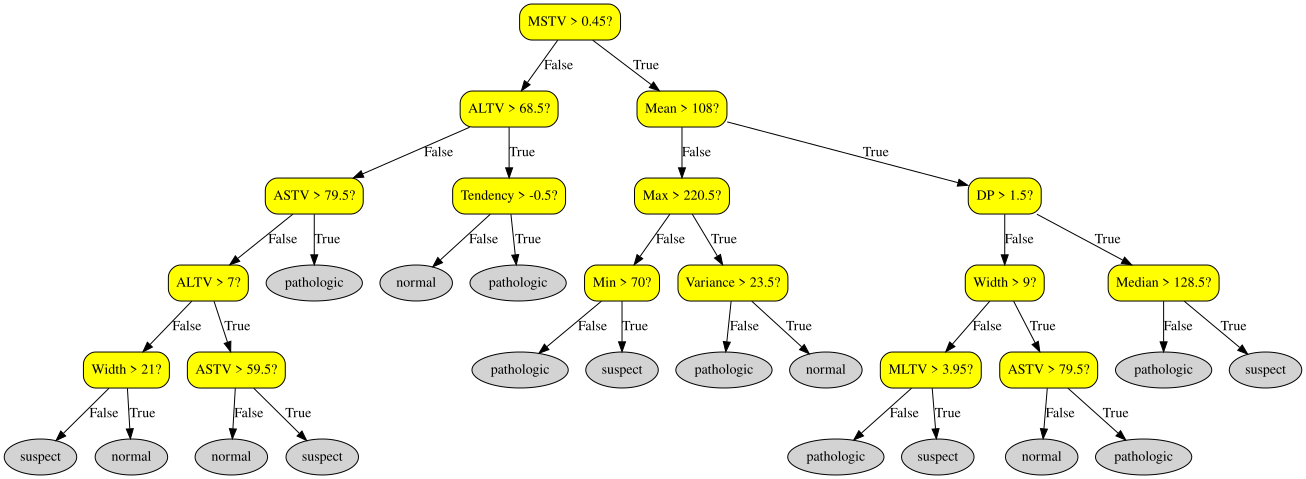

In [ ]:
# Visualize the decision tree
best_cls.draw_tree()

In the decision tree above, you can see how different features are used to determine the fetal heart diagnosis type

# Task 3: A regression example: predicting property prices
We will be using the given dataset about property prices in parts of Sweden, from Hemnet.

We will run the dataset through models with the goal of predicting the price of an apartment, given numerical information such as the number of rooms, the size of the apartment in square meters, the floor, etc.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the Excel file using Pandas.
alldata = pd.read_excel('Hemnet_data.xlsx')

# # Convert the timestamp string to an integer representing the year.
alldata['year'] = pd.DatetimeIndex(alldata['Sold Date']).year

# Convert 'yes' to 1 and 'no' to 0
alldata['Balcony'] = alldata['Balcony'].map({'Yes': 1, 'No': 0})
alldata['Patio'] = alldata['Patio'].map({'Yes': 1, 'No': 0})
alldata['Lift'] = alldata['Lift'].map({'Yes': 1, 'No': 0})

# Select the 12 input columns and the output column.
selected_columns = ['Final Price (kr)', 'year',  'Num of Room', 'Living Area (m²)', 'Balcony', 'Patio','Current Floor', 'Total Floor', 'Lift', 'Built Year', 'Fee (kr/month)', 'Operating Fee (kr/year)']
alldata = alldata[selected_columns]
for i in range(max(alldata.count())):
  if(isinstance(alldata['Fee (kr/month)'][i], str)):
    alldata.loc[i, 'Fee (kr/month)'] = alldata['Fee (kr/month)'][i][:-2]
alldata = alldata.dropna()

# Shuffle.
alldata_shuffled = alldata.sample(frac=1.0, random_state=0)

# Separate the input and output columns.
X = alldata_shuffled.drop('Final Price (kr)', axis=1)
# For the output, we'll use the log of the sales price.
Y = alldata_shuffled['Final Price (kr)'].apply(np.log)

# Split into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

##Baseline Dummy Regressor

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
m1 = DummyRegressor()
cross_validate(m1, Xtrain, Ytrain, scoring='neg_mean_squared_error')

{'fit_time': array([0.00473523, 0.00379658, 0.00387168, 0.00340223, 0.00386715]),
 'score_time': array([0.00137043, 0.00142717, 0.00148249, 0.00130033, 0.00135946]),
 'test_score': array([-0.35548711, -0.35827597, -0.31759722, -0.34236524, -0.35596055])}

Since the cross_validate function returns a negative MSE, we can obtain the average MSE of the 5 folds by using np.mean and multiplying it by -1. We obtain a MSE of 0.3459

In [ ]:
mean_negative_mse = np.mean(cross_validate(m1, Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'])
print(-mean_negative_mse)

0.34593721954567236


##Training other models

We will be training on these 3 models:

1.   sklearn.linear_model.Lasso
2.   sklearn.tree.DecisionTreeRegressor
3.   sklearn.ensemble.RandomForestRegressor

We will be using GridSearchCV to find the optimal hyperparameters to use for each models. We will use the best model obtained and run it on the test set.

#Lasso

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso

lasso_model = Lasso(random_state=9)

param_grid = {
    'alpha': [0.01, 0.1, 1],
    'max_iter': [100, 500, 1000],
    'tol': [1e-5, 1e-4, 1e-3]
}

lasso_grid_search = GridSearchCV(lasso_model, param_grid, cv = 5, scoring='neg_mean_squared_error')

lasso_grid_search.fit(Xtrain, Ytrain)

print("Best Params: ", lasso_grid_search.best_params_)
print("Best MSE: ", -lasso_grid_search.best_score_)
mean_squared_error(Ytest, lasso_grid_search.best_estimator_.predict(Xtest))

Best Params:  {'alpha': 0.01, 'max_iter': 100, 'tol': 0.001}
Best MSE:  0.22150496013693483


0.209504151855485

#Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

decisiontree_model = DecisionTreeRegressor(random_state=9)

param_grid = {
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

decisiontree_grid_search = GridSearchCV(decisiontree_model, param_grid, cv = 5, scoring='neg_mean_squared_error')

decisiontree_grid_search.fit(Xtrain, Ytrain)

print("Best Params: ", decisiontree_grid_search.best_params_)
print("Best MSE: ", -decisiontree_grid_search.best_score_)
mean_squared_error(Ytest, decisiontree_grid_search.best_estimator_.predict(Xtest))

Best Params:  {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best MSE:  0.19821267998012343


0.18487171139657618

#Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

randomforest_model = RandomForestRegressor(random_state=9)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2', None]
}

randomforest_grid_search = GridSearchCV(randomforest_model, param_grid, cv = 5, scoring='neg_mean_squared_error')

randomforest_grid_search.fit(Xtrain, Ytrain)

print("Best Params: ", randomforest_grid_search.best_params_)
print("Best MSE: ", -randomforest_grid_search.best_score_)
mean_squared_error(Ytest, randomforest_grid_search.best_estimator_.predict(Xtest))

Best Params:  {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Best MSE:  0.14704036059953843


0.13358618419906268

#Evaluation of RandomForestRegressor Model

Out of all the models we used, the Random Forest Regressor model obtained the lowest test MSE score of 0.1336.

The optimal hyperparamters to use are:
*   max_depth: 20
*   max_features: sqrt
*   n_estimators: 200